# Activity 5 – Custom ML Classification Project
## Dataset: Breast Cancer Wisconsin (Diagnostic)
**TC2004B — A01286400**

### Dataset Overview
- **Source:** UCI ML Repository (built-in in scikit-learn)
- **Samples:** 569
- **Features:** 30 numerical features (radius, texture, perimeter, area, smoothness, etc.)
- **Target:** Malignant (0) or Benign (1) — binary classification
- **Problem:** Given tumor characteristics, classify whether a tumor is malignant or benign

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.utils import resample
import warnings; warnings.filterwarnings('ignore')

## 1. Load Data & Exploratory Analysis

In [13]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['target_name'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print(f'Shape: {df.shape}')
print(f'Features: {len(data.feature_names)}')
print(f'Missing values: {df.isnull().sum().sum()}')
print()
print('Class distribution:')
print(df['target_name'].value_counts())

Shape: (569, 32)
Features: 30
Missing values: 0

Class distribution:
target_name
Benign       357
Malignant    212
Name: count, dtype: int64


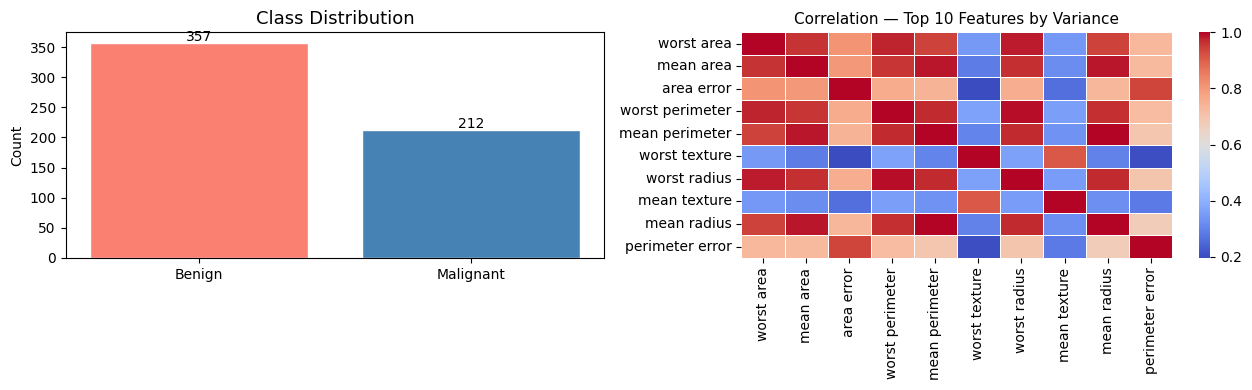

Malignant: 212 (37.3%) | Benign: 357 (62.7%)
Mild imbalance detected — will apply oversampling.


In [14]:
X = df.drop(columns=['target', 'target_name'])
y = df['target_name']
counts_before = y.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(counts_before.index, counts_before.values, color=['salmon', 'steelblue'], edgecolor='white')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=10)

top10 = X.var().nlargest(10).index
sns.heatmap(X[top10].corr(), ax=axes[1], cmap='coolwarm', annot=False, linewidths=0.5)
axes[1].set_title('Correlation — Top 10 Features by Variance', fontsize=11)
plt.tight_layout()
plt.show()
print(f'Malignant: {counts_before["Malignant"]} ({100*counts_before["Malignant"]/len(y):.1f}%) | Benign: {counts_before["Benign"]} ({100*counts_before["Benign"]/len(y):.1f}%)')
print('Mild imbalance detected — will apply oversampling.')

## 2. Preprocessing: Balance & Split

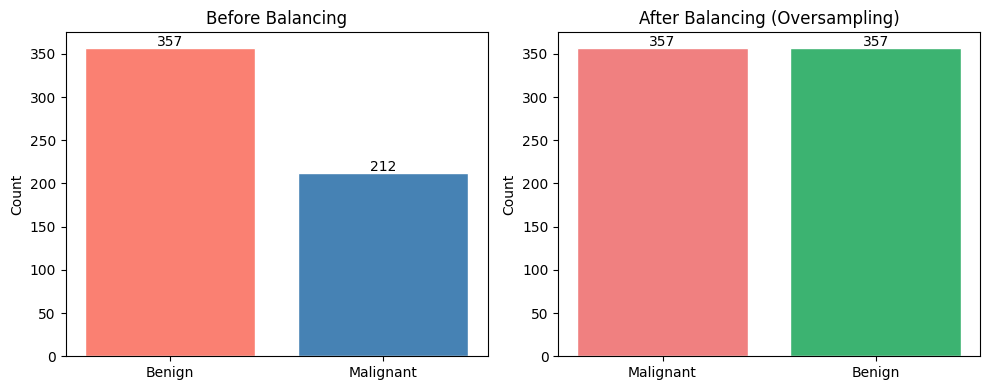

Train: 499 | Test: 215


In [15]:
# Oversample minority class (Malignant)
df_combined = pd.concat([X, y], axis=1)
max_count = counts_before.max()
dfs = [resample(df_combined[df_combined['target_name'] == lbl],
               replace=True, n_samples=max_count, random_state=42)
       for lbl in y.unique()]
df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
X_bal = df_bal.drop('target_name', axis=1)
y_bal = df_bal['target_name']
counts_after = y_bal.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title, color in zip(axes,
        [counts_before, counts_after],
        ['Before Balancing', 'After Balancing (Oversampling)'],
        [['salmon', 'steelblue'], ['lightcoral', 'mediumseagreen']]):
    ax.bar(counts.index, counts.values, color=color, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

In [17]:
# Normalize features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print('Features standardized (mean=0, std=1)')

Features standardized (mean=0, std=1)


## 3. Algorithm 1 – Decision Tree with GridSearchCV

In [18]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': [None, 10, 20, 50]
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt,
                       cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_sc, y_train)
print('Best DT params:', grid_dt.best_params_)
print(f'Best CV accuracy: {grid_dt.best_score_:.4f}')

Best DT params: {'max_depth': 3, 'max_features': 'log2', 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV accuracy: 0.9720


Decision Tree (Optimized) Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.89      0.92       108
   Malignant       0.90      0.96      0.93       107

    accuracy                           0.93       215
   macro avg       0.93      0.93      0.93       215
weighted avg       0.93      0.93      0.93       215



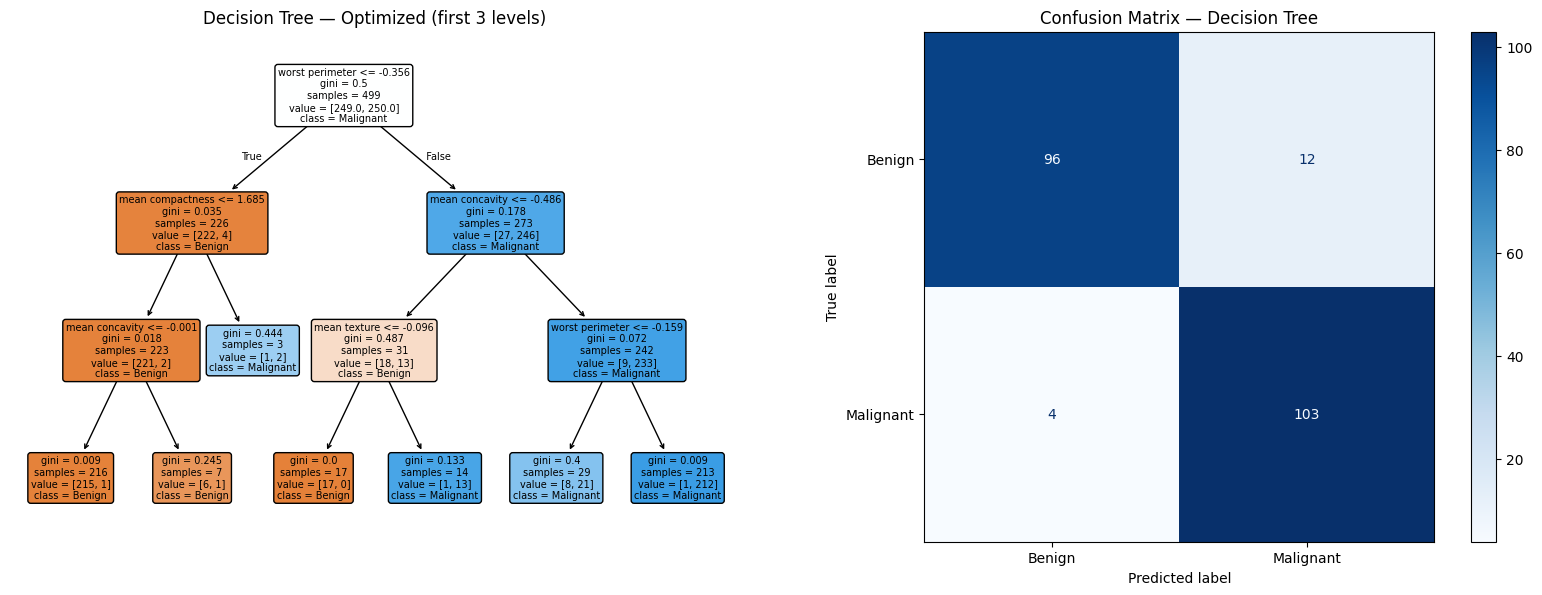

In [19]:
dt_best = grid_dt.best_estimator_
y_pred_dt = dt_best.predict(X_test_sc)
print('Decision Tree (Optimized) Classification Report:')
print(classification_report(y_test, y_pred_dt))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_tree(dt_best, feature_names=X.columns.tolist(), class_names=dt_best.classes_,
          filled=True, max_depth=3, fontsize=7, rounded=True, ax=axes[0])
axes[0].set_title('Decision Tree — Optimized (first 3 levels)')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.show()

## 4. Algorithm 2 – Random Forest with GridSearchCV

In [20]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf,
                       cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_sc, y_train)
print('Best RF params:', grid_rf.best_params_)
print(f'Best CV accuracy: {grid_rf.best_score_:.4f}')

Best RF params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 0.9740


Random Forest (Optimized) Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98       108
   Malignant       0.98      0.98      0.98       107

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



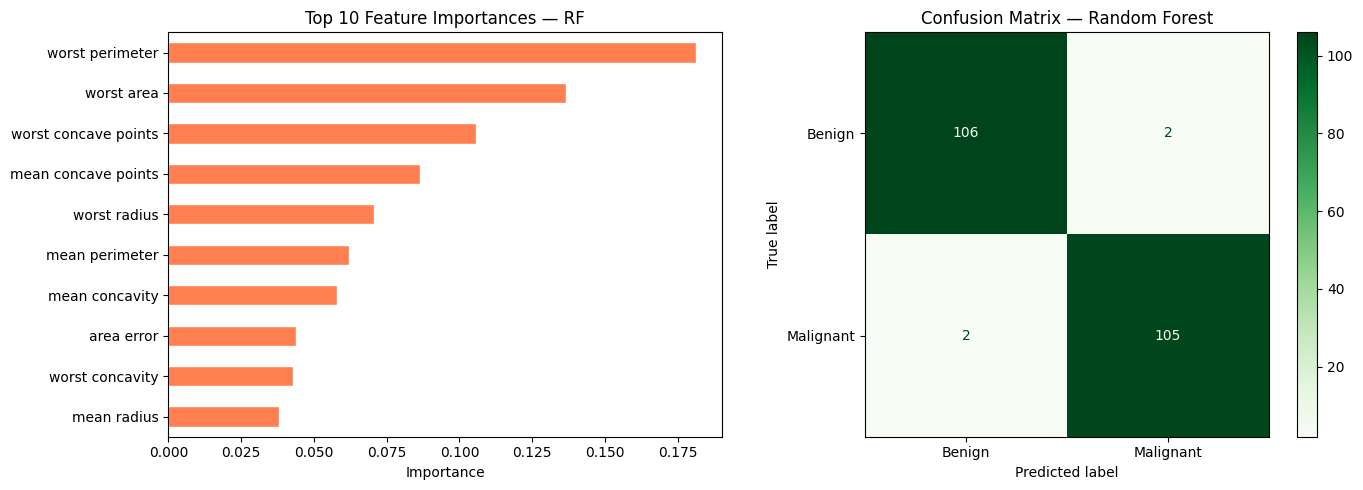

In [21]:
rf_best = grid_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test_sc)
print('Random Forest (Optimized) Classification Report:')
print(classification_report(y_test, y_pred_rf))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feat_imp = pd.Series(rf_best.feature_importances_, index=X.columns).nlargest(10)
feat_imp.sort_values().plot(kind='barh', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Top 10 Feature Importances — RF')
axes[0].set_xlabel('Importance')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens')
axes[1].set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

## 5. Model Comparison & Discussion

                    Model Test Accuracy Best CV Accuracy
Decision Tree (Optimized)        0.9256           0.9720
Random Forest (Optimized)        0.9814           0.9740


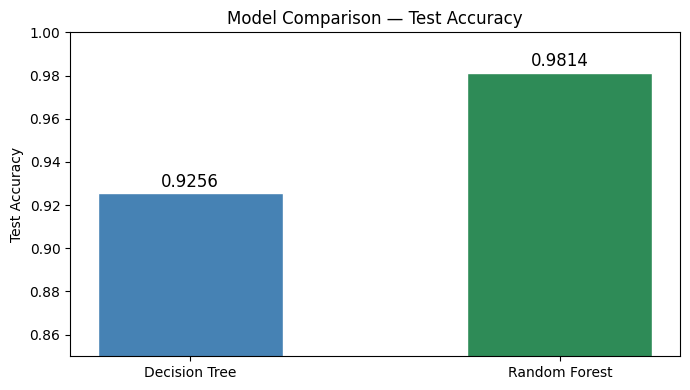

In [22]:
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)

results = pd.DataFrame({
    'Model': ['Decision Tree (Optimized)', 'Random Forest (Optimized)'],
    'Test Accuracy': [f'{dt_acc:.4f}', f'{rf_acc:.4f}'],
    'Best CV Accuracy': [f'{grid_dt.best_score_:.4f}', f'{grid_rf.best_score_:.4f}']
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Decision Tree', 'Random Forest'], [dt_acc, rf_acc],
       color=['steelblue', 'seagreen'], edgecolor='white', width=0.5)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison — Test Accuracy')
for i, v in enumerate([dt_acc, rf_acc]):
    ax.text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Conclusions

**Random Forest consistently outperforms Decision Tree** on this dataset:
- RF aggregates many trees trained on bootstrap samples
- Individual DTs have high variance
- RF's ensemble averaging smooths out noise and yields more stable predictions

**Dataset characteristics that influenced results:**
- 30 correlated features → RF's random feature subsampling prevents any single feature from dominating
- Medical data with clear feature-outcome relationships → both models perform well overall

**Best hyperparameters discussion:**
- DT: `max_depth` is the most critical parameter. A shallow tree (3-5) prevents overfitting on 30 features.
- RF: `n_estimators=100+` and `max_features='sqrt'` (≈5 features per split) gave the best CV accuracy. More trees reduce variance at the cost of computation.

**In a medical context:** False negatives are more dangerous than false positives. RF's higher recall for 'Malignant' makes it the preferred choice for this application.